# VN30 VSA (Volume Spike Analysis) Strategy Backtest

This notebook implements and backtests the **Volume Spike Breakout Strategy** for VN30 stocks.

## Strategy Overview
- **Buy Signal**: Volume spike (V >= 4x MAV20) in last 5 days, then breakout above spike high
- **Position Size**: Max 5 positions, 20% NAV each
- **Stop Loss**: 7% fixed OR close below spike low
- **Trailing Stop**: MA10 (first 7 weeks) / MA50 (after 7 weeks)
- **Take Profit**: Sell 50% at +20%
- **Forced Exit**: Distribution signal (down day + volume spike)

## 1. Setup and Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Import VSA modules
from strategies.vsa.vsa_engine import VSAEngine
from strategies.vsa.performance import calculate_performance_metrics, print_performance_report
from strategies.vsa.performance import analyze_trades_by_exit_reason, analyze_trades_by_stock

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("VSA Backtest Notebook loaded successfully!")

VSA Backtest Notebook loaded successfully!


## 2. Initialize Engine and Load Data

In [2]:
# Configuration
INITIAL_NAV = 1_000_000_000  # 1 billion VND
START_DATE = '2016-01-01'
END_DATE = '2026-01-24'

# Initialize engine
engine = VSAEngine(
    initial_nav=INITIAL_NAV,
    start_date=START_DATE,
    end_date=END_DATE
)

# Load data
engine.load_data('VN30_STOCKS_PRICE.csv')

Loaded data for 30 stocks
Date range: 2016-01-04 to 2026-01-23
Total trading days: 2515


## 3. Run Backtest

In [3]:
# Run backtest
nav_df = engine.run()


Running backtest from 2016-01-04 to 2026-01-23
Initial NAV: 1,000,000,000
--------------------------------------------------
Processed 500/2515 days, NAV: 1,351,069,038, Positions: 2
Processed 1000/2515 days, NAV: 1,636,471,392, Positions: 0
Processed 1500/2515 days, NAV: 2,355,279,361, Positions: 2
Processed 2000/2515 days, NAV: 2,277,956,562, Positions: 0
Processed 2500/2515 days, NAV: 4,288,991,870, Positions: 2
Processed 2515/2515 days, NAV: 4,782,802,606, Positions: 5
--------------------------------------------------
Final NAV: 4,782,802,606
Total trades: 186


## 4. Performance Report

In [4]:
# Get trade history
trades_df = engine.get_trades()

# Calculate metrics
metrics = calculate_performance_metrics(nav_df, trades_df, INITIAL_NAV)

# Print report
print_performance_report(metrics)


           VSA STRATEGY BACKTEST REPORT

📊 PORTFOLIO PERFORMANCE
----------------------------------------
  Initial NAV:          1,000,000,000
  Final NAV:            4,782,802,606
  Total Return:               378.28%
  CAGR:                        16.98%
  Annual Volatility:           10.31%
  Sharpe Ratio:                  1.16
  Max Drawdown:               -11.79%
  Calmar Ratio:                  1.44

📈 TRADE STATISTICS
----------------------------------------
  Total Trades:                   186
  Winning Trades:                  92
  Losing Trades:                   94
  Win Rate:                    49.46%
  Avg Win:                     20.50%
  Avg Loss:                    -4.09%
  Max Win:                     85.99%
  Max Loss:                   -17.24%
  Profit Factor:                 2.46
  Avg Holding Days:              38.7

💰 PROFIT/LOSS
----------------------------------------
  Total P&L:            2,042,605,554
  Gross Profit:         3,445,929,506
  Gross Loss:   

## 5. Equity Curve

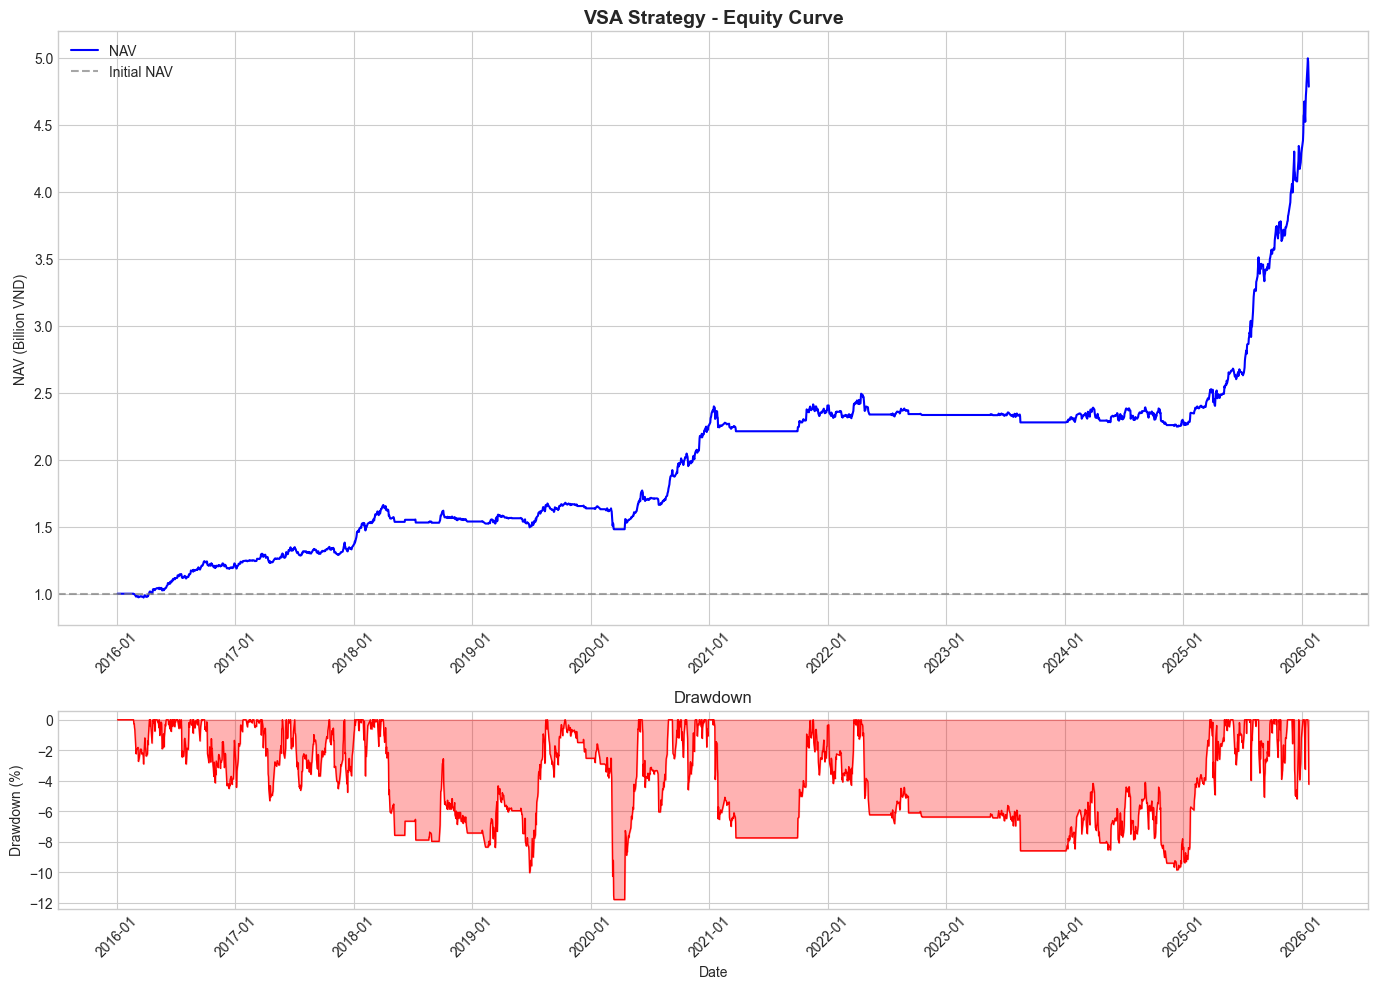


Max Drawdown: -11.79%


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve
ax1 = axes[0]
ax1.plot(nav_df['date'], nav_df['nav'] / 1e9, 'b-', linewidth=1.5, label='NAV')
ax1.axhline(y=INITIAL_NAV / 1e9, color='gray', linestyle='--', alpha=0.7, label='Initial NAV')
ax1.set_title('VSA Strategy - Equity Curve', fontsize=14, fontweight='bold')
ax1.set_ylabel('NAV (Billion VND)')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Drawdown
ax2 = axes[1]
nav_df['peak'] = nav_df['nav'].cummax()
nav_df['drawdown'] = (nav_df['nav'] - nav_df['peak']) / nav_df['peak'] * 100
ax2.fill_between(nav_df['date'], 0, nav_df['drawdown'], color='red', alpha=0.3)
ax2.plot(nav_df['date'], nav_df['drawdown'], 'r-', linewidth=1)
ax2.set_title('Drawdown', fontsize=12)
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print(f"\nMax Drawdown: {metrics['max_drawdown_pct']:.2f}%")

## 6. Trade Analysis

In [6]:
print("\n📊 TRADE ANALYSIS BY EXIT REASON")
print("=" * 60)
exit_analysis = analyze_trades_by_exit_reason(trades_df)
display(exit_analysis)


📊 TRADE ANALYSIS BY EXIT REASON


,Count,Total P&L,Avg P&L,Avg P&L %
exit_reason,,,,
Trailing Stop MA50,92,1.307040e+09,14206955.64,9.0
Take Profit 20%,38,1.604935e+09,42235140.81,22.0
Spike Low Stop,31,-4.195808e+08,-13534864.99,-4.0
Fixed Stop Loss -7%,19,-6.526724e+08,-34351180.34,-9.0
Distribution Signal,6,2.028835e+08,33813920.90,26.0


In [7]:
print("\n📈 TOP 10 STOCKS BY PROFIT")
print("=" * 60)
stock_analysis = analyze_trades_by_stock(trades_df)
display(stock_analysis.head(10))


📈 TOP 10 STOCKS BY PROFIT


,Trades,Total P&L,Avg P&L,Avg P&L %
stock_code,,,,
SHB,10,3.026594e+08,30265942.89,13.0
MWG,7,2.591073e+08,37015326.35,29.0
VPB,6,2.545064e+08,42417725.76,22.0
DGC,14,2.087658e+08,14911844.00,9.0
BCM,20,1.653037e+08,8265185.82,8.0
PLX,6,1.558603e+08,25976723.28,9.0
VIB,12,1.441354e+08,12011281.42,10.0
STB,9,1.393827e+08,15486964.71,11.0
GAS,9,1.340785e+08,14897606.95,5.0


In [8]:
print("\n📉 BOTTOM 10 STOCKS BY PROFIT")
print("=" * 60)
display(stock_analysis.tail(10))


📉 BOTTOM 10 STOCKS BY PROFIT


,Trades,Total P&L,Avg P&L,Avg P&L %
stock_code,,,,
FPT,2,4.997245e+06,2498622.60,1.0
VJC,1,-1.424146e+06,-1424145.57,-0.0
VRE,1,-1.548789e+06,-1548789.35,-1.0
LPB,5,-2.096295e+06,-419259.07,2.0
BID,2,-4.372330e+06,-2186165.12,-1.0
SSI,1,-8.764519e+06,-8764518.65,-3.0
CTG,4,-2.521455e+07,-6303638.10,-3.0
TPB,14,-2.578704e+07,-1841931.18,1.0
MSN,10,-8.952804e+07,-8952803.97,-2.0


## 7. Trade Distribution

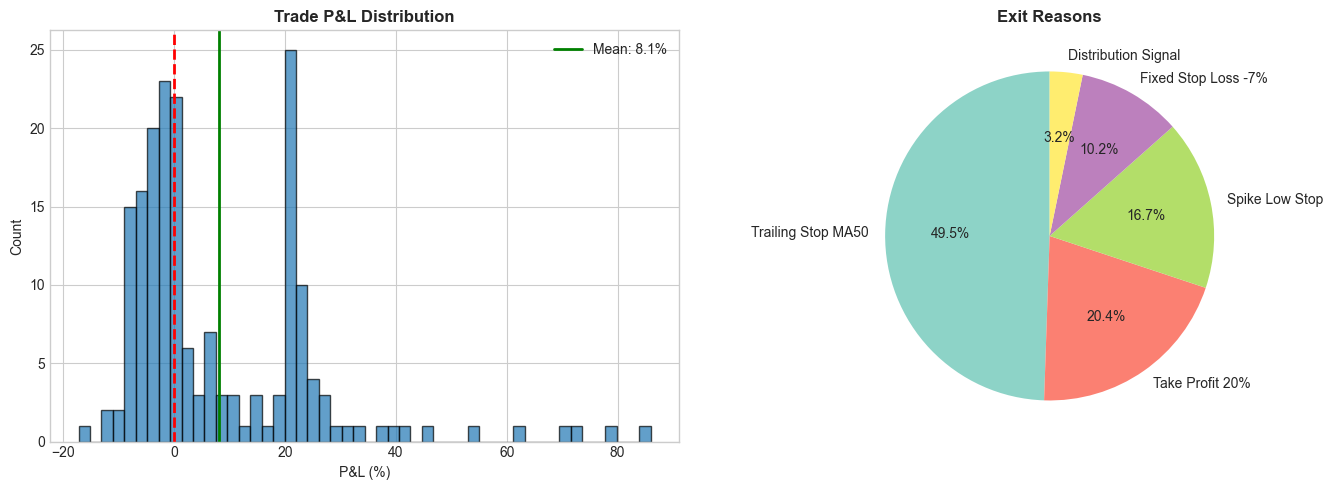

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P&L Distribution
ax1 = axes[0]
pnl_pct = trades_df['pnl_pct'] * 100
ax1.hist(pnl_pct, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.axvline(x=pnl_pct.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {pnl_pct.mean():.1f}%')
ax1.set_title('Trade P&L Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('P&L (%)')
ax1.set_ylabel('Count')
ax1.legend()

# Exit Reason Pie Chart
ax2 = axes[1]
exit_counts = trades_df['exit_reason'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(exit_counts)))
wedges, texts, autotexts = ax2.pie(exit_counts.values, labels=exit_counts.index, 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Exit Reasons', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Sample Trades

In [10]:
print("\n📋 SAMPLE TRADES (Last 20)")
print("=" * 80)
sample_trades = trades_df.tail(20).copy()
sample_trades['pnl_pct'] = (sample_trades['pnl_pct'] * 100).round(2)
sample_trades['pnl'] = sample_trades['pnl'].round(0)
display(sample_trades[['stock_code', 'buy_date', 'buy_price', 'sell_date', 'sell_price', 'pnl_pct', 'exit_reason']])


📋 SAMPLE TRADES (Last 20)


,stock_code,buy_date,buy_price,sell_date,sell_price,pnl_pct,exit_reason
166,TPB,2024-10-02,15540.575244,2024-11-11,14386.132512,-7.43,Fixed Stop Loss -7%
167,LPB,2024-12-03,27072.199459,2025-01-23,32882.191781,21.46,Take Profit 20%
168,LPB,2024-12-03,27072.199459,2025-03-24,31810.958904,17.50,Trailing Stop MA50
169,VIC,2025-03-10,23650.000000,2025-03-25,28450.000000,20.30,Take Profit 20%
170,BCM,2025-03-11,80200.000000,2025-03-31,74800.000000,-6.73,Spike Low Stop
171,CTG,2024-12-27,26609.694818,2025-04-03,26781.149037,0.64,Trailing Stop MA50
172,BCM,2025-04-14,60500.000000,2025-04-15,56500.000000,-6.61,Trailing Stop MA50
173,ACB,2025-04-11,20765.068493,2025-04-24,20180.136986,-2.82,Trailing Stop MA50
174,SHB,2025-03-17,9591.713491,2025-05-15,11680.575540,21.78,Take Profit 20%
175,SHB,2025-03-17,9591.713491,2025-07-01,11370.863309,18.55,Trailing Stop MA50


## 9. Yearly Performance


📅 YEARLY PERFORMANCE
  🟢 2016: +22.31%
  🟢 2017: +12.38%
  🟢 2018: +12.31%
  🟢 2019: +6.37%
  🟢 2020: +37.86%
  🟢 2021: +5.53%
  🔴 2022: -2.97%
  🔴 2023: -2.37%
  🟢 2024: +0.10%
  🟢 2025: +87.82%
  🟢 2026: +9.18%


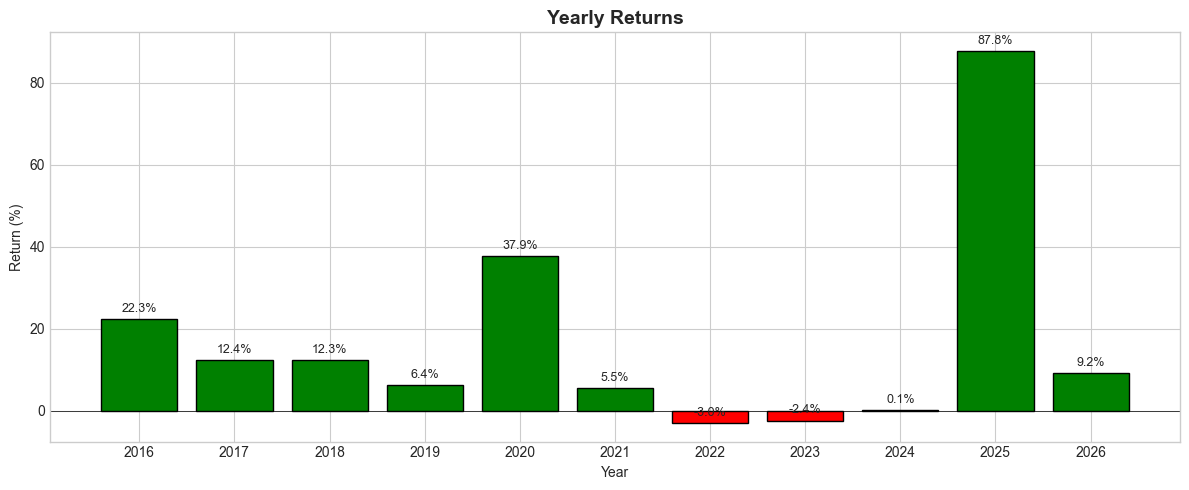

In [ ]:
# Calculate yearly returns
nav_df['year'] = nav_df['date'].dt.year
yearly_nav = nav_df.groupby('year').agg({'nav': ['first', 'last']}).reset_index()
yearly_nav.columns = ['year', 'start_nav', 'end_nav']
yearly_nav['return_pct'] = ((yearly_nav['end_nav'] / yearly_nav['start_nav']) - 1) * 100

print("\n📅 YEARLY PERFORMANCE")
print("=" * 50)
for _, row in yearly_nav.iterrows():
    emoji = '🟢' if row['return_pct'] > 0 else '🔴'
    print(f"  {emoji} {int(row['year'])}: {row['return_pct']:+.2f}%")

# Plot yearly returns
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['green' if x > 0 else 'red' for x in yearly_nav['return_pct']]
bars = ax.bar(yearly_nav['year'].astype(str), yearly_nav['return_pct'], color=colors, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Yearly Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')


ax.set_ylabel('Return (%)')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Summary

In [12]:
print("\n" + "=" * 60)
print("           BACKTEST SUMMARY")
print("=" * 60)
print(f"\n  Period: {START_DATE} to {END_DATE}")
print(f"  Initial NAV: {INITIAL_NAV:,.0f} VND")
print(f"  Final NAV: {metrics['final_nav']:,.0f} VND")
print(f"\n  Total Return: {metrics['total_return_pct']:.2f}%")
print(f"  CAGR: {metrics['cagr_pct']:.2f}%")
print(f"  Max Drawdown: {metrics['max_drawdown_pct']:.2f}%")
print(f"  Sharpe Ratio: {metrics['sharpe_ratio']:.2f}")
print(f"\n  Total Trades: {metrics['total_trades']}")
print(f"  Win Rate: {metrics['win_rate_pct']:.1f}%")
print(f"  Profit Factor: {metrics['profit_factor']:.2f}")
print("\n" + "=" * 60)


           BACKTEST SUMMARY

  Period: 2016-01-01 to 2026-01-24
  Initial NAV: 1,000,000,000 VND
  Final NAV: 4,782,802,606 VND

  Total Return: 378.28%
  CAGR: 16.98%
  Max Drawdown: -11.79%
  Sharpe Ratio: 1.16

  Total Trades: 186
  Win Rate: 49.5%
  Profit Factor: 2.46

